# AIBA: comparación pareada con múltiples replicaciones

Este notebook repite el experimento de bajo presupuesto con semillas independientes. En cada réplica, ambas estrategias comparten los mismos modelos iniciales. Después, AIBA invierte el presupuesto restante dentro de la región recomendada y el baseline lo invierte en nuevas configuraciones amplias.

Cada estrategia consume lógicamente `N_INITIAL_AIBA + N_GUIDED_AIBA` modelos. Al reutilizar la fase inicial compartida solo es necesario entrenar `N_INITIAL_AIBA + 2 × N_GUIDED_AIBA` modelos únicos por réplica. Este diseño pareado reduce ruido y aísla el efecto de decidir dónde gastar el presupuesto restante.

## 1. Configuración

Utiliza `N_REPLICATIONS = 1` para comprobar rápidamente el flujo. Para generar los resultados que se conservarán como evidencia, cambia el valor a `10`, reinicia el kernel y ejecuta todas las celdas. Con los valores predeterminados cada réplica compara 120 modelos lógicos por estrategia y requiere 140 entrenamientos únicos.

In [1]:
# ================================================================
# CONFIGURACIÓN PRINCIPAL
# ================================================================
N_REPLICATIONS = 10          # Prueba rápida: 1; resultados finales: 10
N_INITIAL_AIBA = 100
N_GUIDED_AIBA = 20
BASE_SEED = 2026

N_MODELS_PER_STRATEGY = N_INITIAL_AIBA + N_GUIDED_AIBA
N_UNIQUE_TRAININGS_PER_REPLICATION = N_INITIAL_AIBA + 2 * N_GUIDED_AIBA
print(f'Replicaciones: {N_REPLICATIONS}')
print(f'Modelos lógicos por estrategia y réplica: {N_MODELS_PER_STRATEGY}')
print(f'Entrenamientos únicos por réplica: {N_UNIQUE_TRAININGS_PER_REPLICATION}')
print(f'Entrenamientos únicos totales: {N_REPLICATIONS * N_UNIQUE_TRAININGS_PER_REPLICATION}')

Replicaciones: 10
Modelos lógicos por estrategia y réplica: 120
Entrenamientos únicos por réplica: 140
Entrenamientos únicos totales: 1400


## 2. Preparación

Los resultados se guardan después de cada réplica en `generated_replicated/`. Si una ejecución larga se interrumpe, los CSV contienen todas las réplicas terminadas hasta ese momento.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from replicated_experiment import (
    ExperimentConfig, aggregate_differences, paired_differences, run_replications,
)

HERE = Path.cwd().resolve()
REPOSITORY = (HERE / '../aiba').resolve()
OUTPUT_DIR = HERE / 'generated_replicated'
config = ExperimentConfig(
    n_replications=N_REPLICATIONS,
    n_initial_aiba=N_INITIAL_AIBA,
    n_guided_aiba=N_GUIDED_AIBA,
    base_seed=BASE_SEED,
)
config.validate()
print(config)
print(f'Salida: {OUTPUT_DIR}')


ExperimentConfig(n_replications=10, n_initial_aiba=100, n_guided_aiba=20, base_seed=2026, test_size=0.2, aiba_min_fraction=0.02, aiba_beta=1.0, aiba_initial_step=0.2, aiba_iterative_step=0.01, aiba_max_initial_steps=5, aiba_max_iterations=500)
Salida: C:\Users\aleja\TesisDefinitivos\REPOSITORIO_CATEDRA\AIBA\aiba_budget_comparison\generated_replicated


## 3. Ejecución

Esta celda realiza todos los entrenamientos. Diez réplicas pueden tardar bastante; no cierres el kernel durante la ejecución.

In [3]:
results = run_replications(config, REPOSITORY, OUTPUT_DIR)
replication_summary = results['replication_summary']
differences = paired_differences(replication_summary)
aggregate = aggregate_differences(differences)
differences.to_csv(OUTPUT_DIR / 'paired_differences.csv', index=False)
aggregate.to_csv(OUTPUT_DIR / 'aggregate_differences.csv', index=False)
display(replication_summary)
display(differences)
display(aggregate)


=== Replicación 1/10; semilla 102026 ===


Inicial compartido: 100/100; R²=-0.4711
Extensión guiada: 20/20; R²=0.9618
Extensión amplia: 20/20; R²=-0.5411
Replicación 1: mejor AIBA=0.996939; mejor amplia=0.996939

=== Replicación 2/10; semilla 202026 ===
Inicial compartido: 100/100; R²=-0.4109
Extensión guiada: 20/20; R²=0.55383
Extensión amplia: 20/20; R²=0.98325
Replicación 2: mejor AIBA=0.997439; mejor amplia=0.997439

=== Replicación 3/10; semilla 302026 ===
Inicial compartido: 100/100; R²=0.9721
Extensión guiada: 20/20; R²=0.9926
Extensión amplia: 20/20; R²=0.53912
Replicación 3: mejor AIBA=0.998209; mejor amplia=0.998209

=== Replicación 4/10; semilla 402026 ===
Inicial compartido: 100/100; R²=0.1315
Extensión guiada: 20/20; R²=0.97484
Extensión amplia: 20/20; R²=-0.5332
Replicación 4: mejor AIBA=0.997930; mejor amplia=0.998805

=== Replicación 5/10; semilla 502026 ===
Inicial compartido: 100/100; R²=0.9742
Extensión guiada: 20/20; R²=-0.2206
Extensión amplia: 20/20; R²=-0.6583
R

,replication,strategy,models,best_r2,mean_r2,median_r2,p75_r2,p90_r2,above_090,above_095,training_seconds,search_seconds,total_seconds
0,1,AIBA,120,0.996939,0.269916,0.429989,0.917831,0.988222,34,27,430.519774,7.672477,438.192251
1,1,Broad,120,0.996939,0.133381,-0.031827,0.780637,0.977572,23,16,353.844305,0.000000,353.844305
2,2,AIBA,120,0.997439,0.297893,0.535399,0.960881,0.990653,41,36,518.327308,10.033983,528.361291
3,2,Broad,120,0.997439,0.204314,0.143531,0.923676,0.982512,32,25,409.356081,0.000000,409.356081
4,3,AIBA,120,0.998209,0.156075,0.411675,0.942012,0.991241,37,29,447.817904,6.117567,453.935472
5,3,Broad,120,0.998209,0.035736,-0.015639,0.861508,0.982288,28,21,489.100943,0.000000,489.100943
6,4,AIBA,120,0.997930,0.290595,0.287286,0.935682,0.987545,33,27,283.703801,6.654869,290.358670
7,4,Broad,120,0.998805,0.205683,0.085133,0.912578,0.987545,31,26,276.774991,0.000000,276.774991
8,5,AIBA,120,0.997732,0.223939,0.183749,0.961042,0.987516,40,32,225.697038,6.463481,232.160520
9,5,Broad,120,0.997732,0.135472,-0.009070,0.894093,0.985263,30,25,224.815860,0.000000,224.815860


,replication,delta_best_r2,delta_mean_r2,delta_median_r2,delta_p75_r2,delta_p90_r2,delta_above_090,delta_above_095,delta_total_seconds
0,1,0.000000,0.136535,0.461816,0.137193,0.010651,11.0,11.0,84.347945
1,2,0.000000,0.093579,0.391869,0.037205,0.008141,9.0,11.0,119.005209
2,3,0.000000,0.120339,0.427313,0.080504,0.008953,9.0,8.0,-35.165471
3,4,-0.000875,0.084911,0.202153,0.023104,0.000000,2.0,1.0,13.583679
4,5,0.000000,0.088467,0.192819,0.066949,0.002253,10.0,7.0,7.344660
5,6,0.000000,0.087241,0.269852,0.124532,0.011162,7.0,7.0,54.742787
6,7,0.000930,0.102816,0.465579,0.021254,0.005620,8.0,7.0,225.544925
7,8,0.000977,0.117054,0.391104,0.043859,0.003576,10.0,11.0,40.040915
8,9,-0.000855,0.100445,0.460790,0.049177,0.003623,6.0,5.0,59.474770
9,10,-0.000211,0.172028,0.581112,0.068013,0.002272,16.0,14.0,27.324573


,metric,replications,mean_difference_aiba_minus_broad,std_difference,ci95_low,ci95_high,aiba_wins,ties,broad_wins
0,best_r2,10,-0.000003,0.000611,-0.000382,0.000375,2,5,3
1,mean_r2,10,0.110342,0.027347,0.093392,0.127291,10,0,0
2,median_r2,10,0.384441,0.125652,0.306561,0.462320,10,0,0
3,p75_r2,10,0.065179,0.039648,0.040605,0.089753,10,0,0
4,p90_r2,10,0.005625,0.003884,0.003218,0.008033,9,1,0
5,above_090,10,8.800000,3.614784,6.559533,11.040467,10,0,0
6,above_095,10,8.200000,3.705851,5.903090,10.496910,10,0,0
7,total_seconds,10,59.624399,72.230832,14.855266,104.393533,9,0,1


## 4. Diferencias pareadas por réplica

Cada punto representa `AIBA − búsqueda amplia` dentro de la misma réplica. En las métricas R² y en los conteos de modelos buenos, valores positivos favorecen a AIBA. En tiempo total, un valor positivo significa que AIBA tardó más.

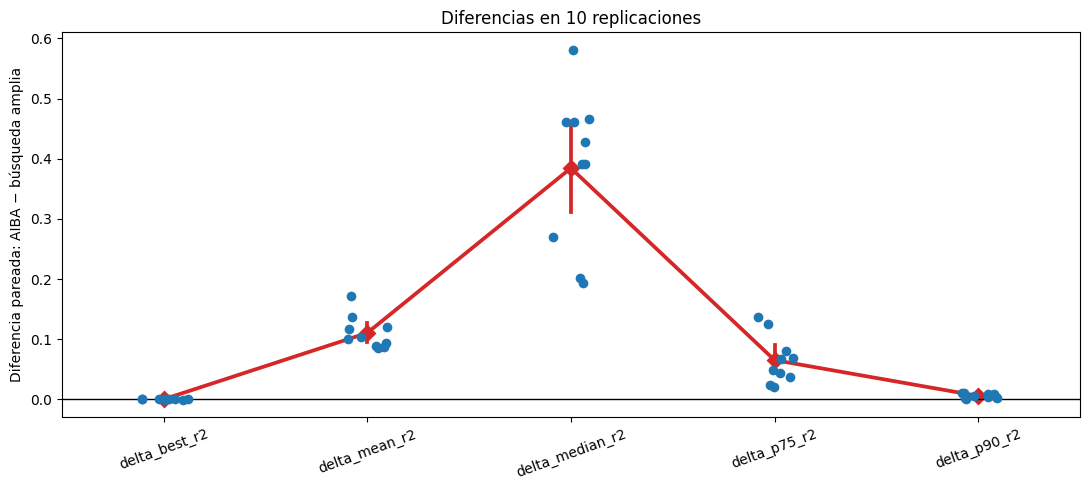

In [4]:
quality_columns = ['delta_best_r2', 'delta_mean_r2', 'delta_median_r2', 'delta_p75_r2', 'delta_p90_r2']
quality_long = differences.melt(
    id_vars='replication', value_vars=quality_columns,
    var_name='metric', value_name='aiba_minus_broad',
)
plt.figure(figsize=(11, 5))
sns.stripplot(data=quality_long, x='metric', y='aiba_minus_broad', jitter=0.12, size=7)
sns.pointplot(data=quality_long, x='metric', y='aiba_minus_broad', errorbar=('ci', 95), color='tab:red', markers='D')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Diferencia pareada: AIBA − búsqueda amplia')
plt.xlabel('')
plt.xticks(rotation=20)
plt.title(f'Diferencias en {N_REPLICATIONS} replicaciones')
plt.tight_layout()
plt.show()

## 5. Eficiencia a medida que se consume el presupuesto

La curva muestra la media acumulada de R² de todos los modelos consumidos hasta cada punto del presupuesto. A diferencia del máximo acumulado, esta medida refleja la calidad general de las configuraciones encontradas. Ambas estrategias son idénticas durante la fase inicial compartida y divergen cuando comienza la extensión de 20 modelos.

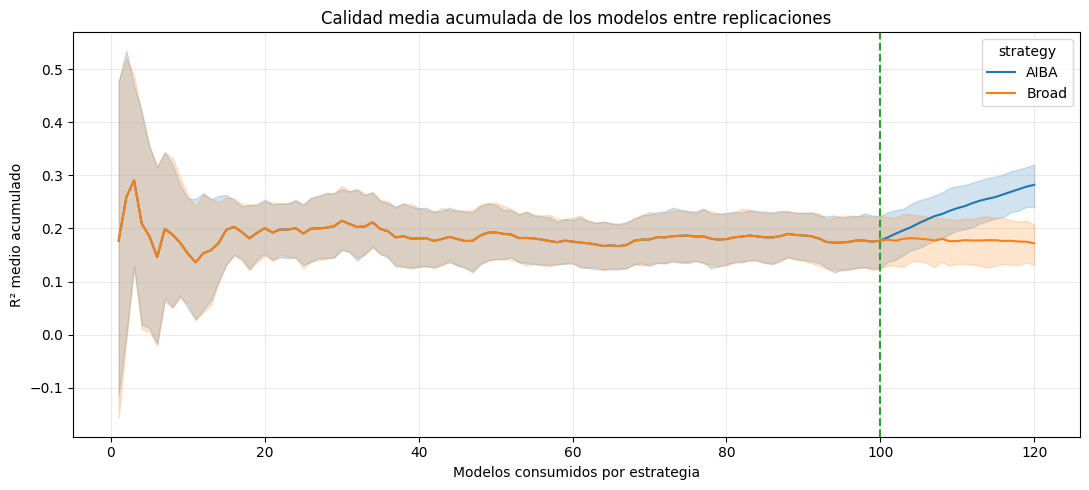

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Permite ejecutar solo esta celda: reutiliza los resultados en memoria o el CSV guardado.
if 'results' in globals() and 'logical_results' in results:
    cumulative = results['logical_results'].copy()
else:
    output_dir = globals().get('OUTPUT_DIR', Path.cwd().resolve() / 'generated_replicated')
    cumulative = pd.read_csv(Path(output_dir) / 'logical_results.csv')

group_columns = ['replication', 'strategy']
cumulative['budget'] = cumulative.groupby(group_columns, sort=False).cumcount() + 1
cumulative['cumulative_mean_r2'] = (
    cumulative.groupby(group_columns, sort=False)['r2']
    .transform(lambda values: values.expanding().mean())
)
initial_budget = globals().get('N_INITIAL_AIBA', 100)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=cumulative,
    x='budget',
    y='cumulative_mean_r2',
    hue='strategy',
    errorbar=('ci', 95),
)
plt.axvline(initial_budget, color='tab:green', linestyle='--', label='Inicio de la extensión')
plt.xlabel('Modelos consumidos por estrategia')
plt.ylabel('R² medio acumulado')
plt.title('Calidad media acumulada de los modelos entre replicaciones')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Interpretación

No es necesario que AIBA gane siempre en el máximo absoluto para resultar útil. Si mejora de forma consistente la media, mediana, percentiles o frecuencia de modelos por encima de un umbral, está aumentando la densidad de configuraciones buenas dentro de un presupuesto bajo. La conclusión debe basarse en las diferencias pareadas de las diez réplicas, no en una única semilla.

Este experimento iguala el número de modelos lógicos. También informa del tiempo, porque configuraciones con más neuronas o épocas pueden consumir recursos distintos aunque el número de entrenamientos sea idéntico.